# Assignment: week 3

The objectives of this assignment are:

1. to work with image data
2. to experiment with pretrained convnets

In [56]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras import layers
from keras.models import Sequential, load_model
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.applications.vgg16 import preprocess_input

## Data preparation

For this assignment, I cloned the CIFAR-10 image dataset.
I loaded the original training set and split it into:

- Training set (80%)
- Validation set (20%)


I then used the original test set as a separate test split.

All datasets were loaded with a batch size of 32, and all images were resized to 32 x 32 pixels.

In [58]:
batch_size = 32
img_size = (32, 32)

train_dir = os.path.abspath("../datasets/CIFAR-10-images/train")
test_dir = os.path.abspath("../datasets/CIFAR-10-images/test")

train_dataset, validation_dataset = keras.utils.image_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    image_size=img_size,
    label_mode="categorical",
    validation_split=0.2,
    subset="both",
    seed=123
)

test_dataset = keras.utils.image_dataset_from_directory(
    test_dir,
    batch_size=batch_size,
    image_size=img_size,
    label_mode="categorical"
)

num_classes = len(train_dataset.class_names)

Found 50000 files belonging to 10 classes.
Using 40000 files for training.
Using 10000 files for validation.
Found 10000 files belonging to 10 classes.


In the following cell I build the convolutional base using `VGG16`. The convolutional base is then frozen so the model can retain learned features from the data. This way, the model is trained **only** on a new classifier top with custom-made layers.

In [59]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3)
)
conv_base.trainable = False

The ``extract_features`` function is used to precompute feature representations from a dataset using afformentioned VGG16 convolutional base. Doing this speeds up training and reduces computation, which was pretty expensive without feature extraction.

In [60]:
def extract_features(dataset):
    features = []
    labels = []

    for images, batch_labels in dataset:
        preprocessed = keras.applications.vgg16.preprocess_input(images)
        batch_features = conv_base(preprocessed, training=False)
        features.append(batch_features)
        labels.append(batch_labels)

    return np.concatenate(features), np.concatenate(labels)


train_features, train_labels = extract_features(train_dataset)
val_features, val_labels = extract_features(validation_dataset)
test_features, test_labels = extract_features(test_dataset)

## Model

The model built in the following cell is done Sequentially:
1. I flattened the data into a 1D Vector that takes shape from the training data (excluding the batch size)
2. Built a Dense layer with 64 units
3. Disabled half of the neurons with Dropout
4. Built a smaller 16 unit Dense layer
5. Disabled 30% of those neurons
6. Finally built the output layer using softmax and the number of classes (10)


Some experimentations were made during training with bigger Dense layers, fewer layers and many different Dropout values.

I ended up using two Dense layers with relatively small numbers of units, which helped reduce overfitting. This worked better than using fewer layers with larger unit sizes, which previously caused the model to overfit massively.

In [88]:
model = keras.Sequential([
    layers.Flatten(input_shape=train_features.shape[1:]),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

In [83]:
opt = Adam()
model.compile(loss="categorical_crossentropy",
              optimizer=opt,
              metrics=["accuracy"])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,042 (132.98 KB)

 Trainable params: 34,042 (132.98 KB)

 Non-trainable params: 0 (0.00 B)

I added ``ModelCheckpoint`` and ``EarlyStopping`` as callbacks during the training.

- ModelCheckpoint creates a separate checkpoint file where it saves weights at some intervals. From there the model and the weights can be loaded to continue training from the state saved.

- EarlyStopping monitors a predetermined metric during the training and stops the process if no improvement has occured for a number of epochs determined by `patience`.

In [84]:
callbacks = [
    ModelCheckpoint(
        filepath="feature_extraction_without_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True)
]

Model is trained for 30 epochs.

During initial training without feature extraction, each epoch took around 2–3 minutes to complete. Now, with feature extraction, we can see that training speed increased significantly due to the greatly reduced computational cost.

In [85]:
history = model.fit(
    train_features,
    train_labels,
    epochs=30,
    validation_data=(val_features, val_labels),
    callbacks=callbacks
)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1199 - loss: 2.8447 - val_accuracy: 0.1022 - val_loss: 2.2998
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1993 - loss: 2.0925 - val_accuracy: 0.3385 - val_loss: 1.7124
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2904 - loss: 1.8318 - val_accuracy: 0.4216 - val_loss: 1.5339
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3704 - loss: 1.6830 - val_accuracy: 0.5039 - val_loss: 1.4041
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4217 - loss: 1.5598 - val_accuracy: 0.5299 - val_loss: 1.3219
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4603 - loss: 1.4756 - val_accuracy: 0.5257 - val_loss: 1.2769
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4753 - loss: 1.4393 - val_accuracy: 0.5523 - val_loss: 1.2511
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4883 - loss: 1.4113 - 

## Visualization

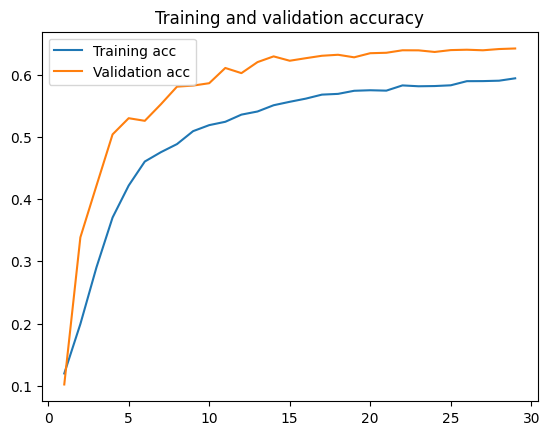

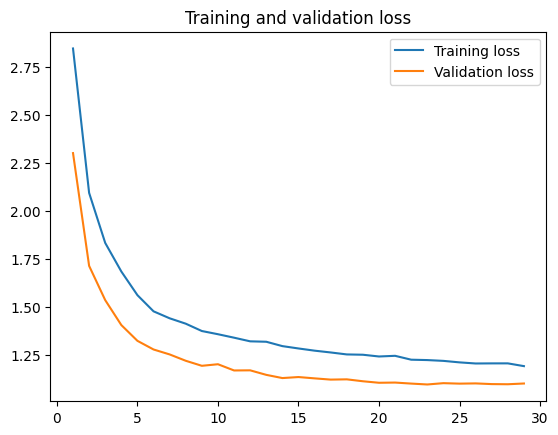

In [86]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()        

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [87]:
test_loss, test_acc = model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6442 - loss: 1.0921
Test accuracy: 0.644


## Summary

The visualization shows steady learning throughout training: both accuracy curves increased while both loss curves decreased. Validation accuracy stayed slightly above training accuracy and ended around ``0.64``, while validation loss remained below training loss, suggesting the model generalized well and did not show strong overfitting. On the test set, the model reached a test accuracy of ``0.643``, which is consistent with the validation results and indicates solid performance for this feature-extraction setup.